In [57]:
import pandas as pd

In [58]:
customers = pd.read_csv(r"C:\Users\PC\Desktop\ATR\data\customers.csv")
extra = pd.read_csv(r"C:\Users\PC\Desktop\ATR\data\extra_orders.csv")
orders = pd.read_csv(r"C:\Users\PC\Desktop\ATR\data\orders.csv")


In [59]:
customers


,customer_id,name,city,age
0,1,Ali,Cairo,22
1,2,Sara,Giza,28
2,3,Omar,Cairo,35
3,4,Mona,Alex,24
4,5,Youssef,Giza,31
5,6,Nour,Cairo,27


In [60]:
orders

,order_id,customer_id,amount
0,101,1,250
1,102,2,400
2,103,1,150
3,104,3,700
4,105,5,300
5,106,2,500
6,107,4,350


In [61]:
extra

,order_id,customer_id,amount
0,108,3,450
1,109,6,275


In [62]:
age_higherthan_25 = customers[customers["age"]>25]
age_higherthan_25

,customer_id,name,city,age
1,2,Sara,Giza,28
2,3,Omar,Cairo,35
4,5,Youssef,Giza,31
5,6,Nour,Cairo,27


In [63]:
from_cairo = customers[customers["city"] == "Cairo"]
from_cairo

,customer_id,name,city,age
0,1,Ali,Cairo,22
2,3,Omar,Cairo,35
5,6,Nour,Cairo,27


In [64]:
both_condations = customers[(customers["age"]>25) & (customers["city"] == "Cairo")]
both_condations

,customer_id,name,city,age
2,3,Omar,Cairo,35
5,6,Nour,Cairo,27


In [65]:
ordedrs_higherthanORequal_300 = orders[orders["amount"] >= 300]
ordedrs_higherthanORequal_300


,order_id,customer_id,amount
1,102,2,400
3,104,3,700
4,105,5,300
5,106,2,500
6,107,4,350


In [66]:
customers.sort_values(by= "age" , ascending=True)

,customer_id,name,city,age
0,1,Ali,Cairo,22
3,4,Mona,Alex,24
5,6,Nour,Cairo,27
1,2,Sara,Giza,28
4,5,Youssef,Giza,31
2,3,Omar,Cairo,35


In [67]:
customers.sort_values(by= "age" , ascending=False)

,customer_id,name,city,age
2,3,Omar,Cairo,35
4,5,Youssef,Giza,31
1,2,Sara,Giza,28
5,6,Nour,Cairo,27
3,4,Mona,Alex,24
0,1,Ali,Cairo,22


In [68]:
customers.sort_values(by=["city","age"] , ascending= [True,False])

,customer_id,name,city,age
3,4,Mona,Alex,24
2,3,Omar,Cairo,35
5,6,Nour,Cairo,27
0,1,Ali,Cairo,22
4,5,Youssef,Giza,31
1,2,Sara,Giza,28


In [69]:
costumers = customers.set_index("customer_id")
costumers

,name,city,age
customer_id,,,
1,Ali,Cairo,22
2,Sara,Giza,28
3,Omar,Cairo,35
4,Mona,Alex,24
5,Youssef,Giza,31
6,Nour,Cairo,27


In [70]:
customers.loc[3]

customer_id       4
name           Mona
city           Alex
age              24
Name: 3, dtype: object

In [71]:
costumers.iloc[0]

name      Ali
city    Cairo
age        22
Name: 1, dtype: object

In [72]:
group = costumers.groupby("city")
group["age"].mean()

city
Alex     24.0
Cairo    28.0
Giza     29.5
Name: age, dtype: float64

In [73]:
group["name"].count()

city
Alex     1
Cairo    3
Giza     2
Name: name, dtype: int64

In [74]:
group1 = orders.groupby("customer_id")
group1["amount"].sum()

customer_id
1    400
2    900
3    700
4    350
5    300
Name: amount, dtype: int64

In [75]:
group1["amount"].agg(["sum","mean","max"])

,sum,mean,max
customer_id,,,
1,400,200.0,250
2,900,450.0,500
3,700,700.0,700
4,350,350.0,350
5,300,300.0,300


In [76]:
customers.merge(orders , how = "inner" , on= "customer_id")


,customer_id,name,city,age,order_id,amount
0,1,Ali,Cairo,22,101,250
1,1,Ali,Cairo,22,103,150
2,2,Sara,Giza,28,102,400
3,2,Sara,Giza,28,106,500
4,3,Omar,Cairo,35,104,700
5,4,Mona,Alex,24,107,350
6,5,Youssef,Giza,31,105,300


In [77]:
merged = customers.merge(orders , how = "left" , on= "customer_id")
merged

,customer_id,name,city,age,order_id,amount
0,1,Ali,Cairo,22,101.0,250.0
1,1,Ali,Cairo,22,103.0,150.0
2,2,Sara,Giza,28,102.0,400.0
3,2,Sara,Giza,28,106.0,500.0
4,3,Omar,Cairo,35,104.0,700.0
5,4,Mona,Alex,24,107.0,350.0
6,5,Youssef,Giza,31,105.0,300.0
7,6,Nour,Cairo,27,NaN,NaN


In [78]:
pd.concat([orders,extra],ignore_index=True)

,order_id,customer_id,amount
0,101,1,250
1,102,2,400
2,103,1,150
3,104,3,700
4,105,5,300
5,106,2,500
6,107,4,350
7,108,3,450
8,109,6,275


In [79]:
customers.set_index("customer_id").join(orders.set_index("customer_id"),on="customer_id" ,how="inner",lsuffix="_left",rsuffix="right")

,name,city,age,order_id,amount
customer_id,,,,,
1,Ali,Cairo,22,101,250
1,Ali,Cairo,22,103,150
2,Sara,Giza,28,102,400
2,Sara,Giza,28,106,500
3,Omar,Cairo,35,104,700
4,Mona,Alex,24,107,350
5,Youssef,Giza,31,105,300


In [80]:
merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  8 non-null      int64  
 1   name         8 non-null      str    
 2   city         8 non-null      str    
 3   age          8 non-null      int64  
 4   order_id     7 non-null      float64
 5   amount       7 non-null      float64
dtypes: float64(2), int64(2), str(2)
memory usage: 516.0 bytes


In [81]:
merged.describe()

,customer_id,age,order_id,amount
count,8.00000,8.00000,7.000000,7.000000
mean,3.00000,27.12500,104.000000,378.571429
std,1.85164,4.48609,2.160247,179.947082
min,1.00000,22.00000,101.000000,150.000000
25%,1.75000,23.50000,102.500000,275.000000
50%,2.50000,27.50000,104.000000,350.000000
75%,4.25000,28.75000,105.500000,450.000000
max,6.00000,35.00000,107.000000,700.000000


In [82]:
merged.isnull().sum()


customer_id    0
name           0
city           0
age            0
order_id       1
amount         1
dtype: int64

In [83]:
#data types =>  float64(2), int64(2), str(2)
#missing-value counts => 2 (1 at order_id + 1 at amount)
#missing-value percentages = 2/(6*8) * 100 = 4.16666666
missing = merged.isnull().mean()*100
print(missing)
merged[merged.isnull().any(axis=1)]

customer_id     0.0
name            0.0
city            0.0
age             0.0
order_id       12.5
amount         12.5
dtype: float64


,customer_id,name,city,age,order_id,amount
7,6,Nour,Cairo,27,NaN,NaN


In [84]:
merged.duplicated().sum()

np.int64(0)

In [85]:
merged[merged.duplicated()]

,customer_id,name,city,age,order_id,amount


In [86]:
merged.loc[len(merged)] = [1,"Ali","Cairo",22,101,250]

In [87]:
merged

,customer_id,name,city,age,order_id,amount
0,1,Ali,Cairo,22,101.0,250.0
1,1,Ali,Cairo,22,103.0,150.0
2,2,Sara,Giza,28,102.0,400.0
3,2,Sara,Giza,28,106.0,500.0
4,3,Omar,Cairo,35,104.0,700.0
5,4,Mona,Alex,24,107.0,350.0
6,5,Youssef,Giza,31,105.0,300.0
7,6,Nour,Cairo,27,NaN,NaN
8,1,Ali,Cairo,22,101.0,250.0


In [88]:
merged.duplicated().sum()

np.int64(1)

In [89]:
merged[merged.duplicated()]

,customer_id,name,city,age,order_id,amount
8,1,Ali,Cairo,22,101.0,250.0


In [90]:
merged = merged.drop_duplicates()
merged

,customer_id,name,city,age,order_id,amount
0,1,Ali,Cairo,22,101.0,250.0
1,1,Ali,Cairo,22,103.0,150.0
2,2,Sara,Giza,28,102.0,400.0
3,2,Sara,Giza,28,106.0,500.0
4,3,Omar,Cairo,35,104.0,700.0
5,4,Mona,Alex,24,107.0,350.0
6,5,Youssef,Giza,31,105.0,300.0
7,6,Nour,Cairo,27,NaN,NaN


In [91]:
merged.duplicated().sum()

np.int64(0)

In [92]:
merged.dtypes

customer_id      int64
name               str
city               str
age              int64
order_id       float64
amount         float64
dtype: object

In [93]:
merged["city"] = merged["city"].astype("category")

In [94]:
merged.dtypes

customer_id       int64
name                str
city           category
age               int64
order_id        float64
amount          float64
dtype: object

In [95]:
merged["order_date"] = pd.date_range(
    start="2026-09-01",
    periods=len(merged)
)

In [96]:
merged.dtypes

customer_id             int64
name                      str
city                 category
age                     int64
order_id              float64
amount                float64
order_date     datetime64[us]
dtype: object

In [97]:
pivot = pd.pivot_table (merged,index="city",values="amount",aggfunc=["sum","mean"])
pivot

,sum,mean
,amount,amount
city,,
Alex,350.0,350.000000
Cairo,1100.0,366.666667
Giza,1200.0,400.000000


In [98]:
def classify_amount(a):
    if pd.isna(a):
        return "No Order"
    elif a >= 400:
        return "High"
    else:
        return "Normal"

merged["ordeer_level"] = merged["amount"].apply(classify_amount)
merged

,customer_id,name,city,age,order_id,amount,order_date,ordeer_level
0,1,Ali,Cairo,22,101.0,250.0,2026-09-01,Normal
1,1,Ali,Cairo,22,103.0,150.0,2026-09-02,Normal
2,2,Sara,Giza,28,102.0,400.0,2026-09-03,High
3,2,Sara,Giza,28,106.0,500.0,2026-09-04,High
4,3,Omar,Cairo,35,104.0,700.0,2026-09-05,High
5,4,Mona,Alex,24,107.0,350.0,2026-09-06,Normal
6,5,Youssef,Giza,31,105.0,300.0,2026-09-07,Normal
7,6,Nour,Cairo,27,NaN,NaN,2026-09-08,No Order


In [ ]:
merged["amount"].mean()

np.float64(378.57142857142856)

In [102]:
merged["amount"].median()

np.float64(350.0)

In [103]:
merged["amount"].std()

np.float64(179.94708216848747)

In [104]:
merged["amount"].quantile([0.25,0.5,0.75])

0.25    275.0
0.50    350.0
0.75    450.0
Name: amount, dtype: float64

<Axes: >

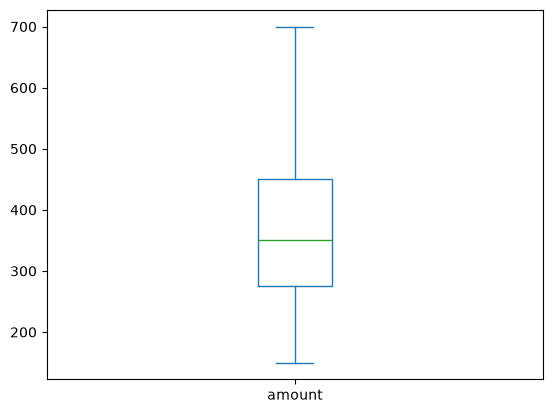

In [111]:

merged["amount"].plot.box()

<Axes: ylabel='Frequency'>

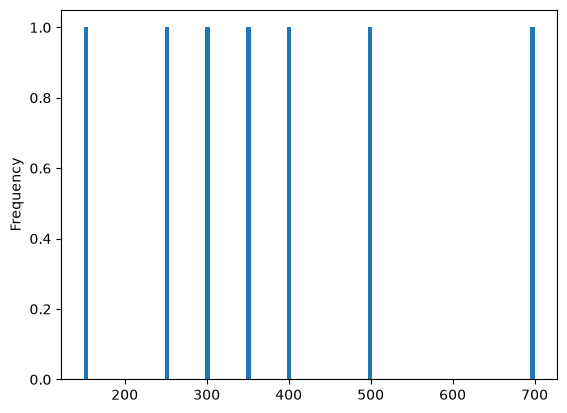

In [125]:
merged["amount"].plot.hist(bins=100)

In [117]:
merged["amount"].describe()

count      7.000000
mean     378.571429
std      179.947082
min      150.000000
25%      275.000000
50%      350.000000
75%      450.000000
max      700.000000
Name: amount, dtype: float64

<Axes: xlabel='age', ylabel='amount'>

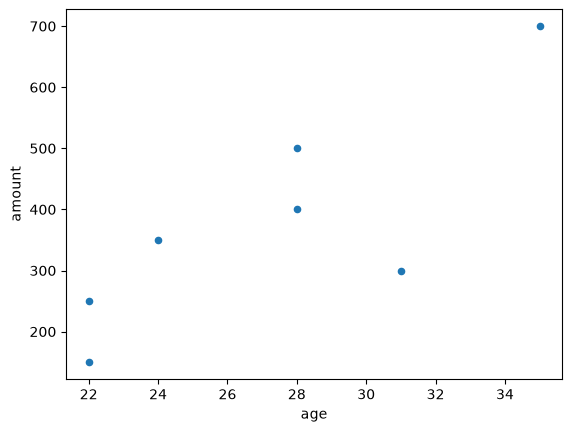

In [122]:
merged.plot.scatter(x= "age" ,y= "amount")

In [123]:
merged[["age","amount"]].corr()


,age,amount
age,1.000000,0.816513
amount,0.816513,1.000000


<Axes: xlabel='name'>

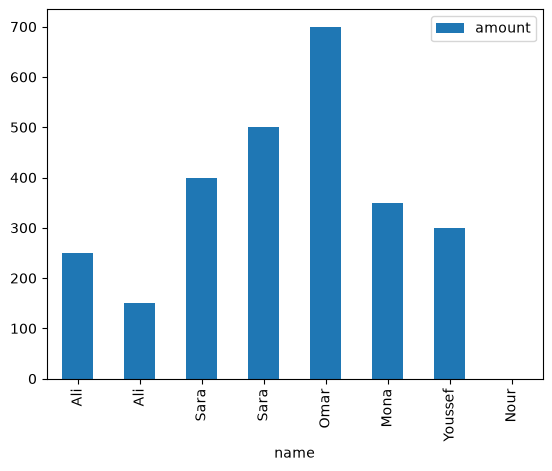

: 

In [ ]:
merged.plot(kind="bar",x="name",y="amount")